# DSA 210 Project -  Analyzing and Predicting Procrastination Behavior Using Daily Digital Habits


My project is about understanding how my daily habits affect how much I procrastinate. I tracked things like how much I sleep, how long I study, how much I use social media, and how stressed I feel — and then gave myself a procrastination score each day.

The data covers every activity since 03-03-2026. I collected it manually based on my daily routine.

*the updated version

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.simplefilter('ignore')

%matplotlib inline

In [5]:
df = pd.read_csv('procrastination_data.csv', parse_dates=['date'])
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Rows: 42, Columns: 9


,date,sleep_hours,study_hours,screen_time,social_media_time,planned_tasks,completed_tasks,stress_level,procrastination_score
0,2026-03-03,6.8,1.7,4.5,2.9,7,5,6,3.9
1,2026-04-03,6.4,2.0,4.5,2.8,6,2,5,7.0
2,2026-05-03,6.9,2.6,4.5,2.0,3,1,5,1.4
3,2026-06-03,7.4,2.1,4.7,2.5,6,3,5,5.3
4,2026-07-03,6.4,1.3,4.4,2.7,5,2,6,5.7
5,2026-08-03,6.4,2.6,6.0,3.7,6,3,7,7.9
6,2026-09-03,7.4,1.7,5.2,3.2,4,3,6,4.1
7,2026-10-03,7.0,2.9,4.3,1.8,4,2,7,1.7
8,2026-11-03,6.2,1.8,4.8,3.2,5,4,6,4.1
9,2026-12-03,6.8,3.7,4.5,2.7,3,1,8,5.1


In [6]:
df.describe()

,date,sleep_hours,study_hours,screen_time,social_media_time,planned_tasks,completed_tasks,stress_level,procrastination_score
count,42,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,2026-05-15 08:34:17.142857216,6.388095,2.500000,5.002381,2.983333,5.214286,2.714286,6.214286,5.152381
min,2026-01-04 00:00:00,5.300000,1.200000,3.100000,1.200000,3.000000,1.000000,4.000000,1.000000
25%,2026-03-19 06:00:00,6.025000,1.825000,4.500000,2.625000,4.000000,2.000000,5.000000,3.925000
50%,2026-03-29 12:00:00,6.400000,2.700000,4.750000,2.950000,5.500000,3.000000,6.000000,5.000000
75%,2026-07-03 18:00:00,6.700000,2.975000,5.650000,3.550000,6.000000,3.000000,7.000000,6.575000
max,2026-12-04 00:00:00,7.600000,4.000000,7.300000,4.100000,7.000000,5.000000,10.000000,10.000000
std,NaN,0.558396,0.748657,0.846366,0.672787,1.335002,1.174645,1.423423,1.991352


In [7]:
print(f'Bad rows (completed > planned): {(df.completed_tasks > df.planned_tasks).sum()}')
df['task_completion_rate'] = df['completed_tasks'] / df['planned_tasks']
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df[['date', 'planned_tasks', 'completed_tasks', 'task_completion_rate', 'is_weekend']].head()

Bad rows (completed > planned): 0


,date,planned_tasks,completed_tasks,task_completion_rate,is_weekend
0,2026-03-03,7,5,0.714286,False
1,2026-04-03,6,2,0.333333,False
2,2026-05-03,3,1,0.333333,True
3,2026-06-03,6,3,0.500000,False
4,2026-07-03,5,2,0.400000,False


In [8]:
def fmean(data):
    s = 0
    for x in data:
        s += x
    return s / len(data)
def fvar(data):
    mean = fmean(data)
    s = 0
    for x in data:
        s += (x - mean) ** 2
    return s / len(data)
def fstd(data):
    return np.sqrt(fvar(data))
def fmedian(data):
    v = np.sort(data)
    l = len(v)
    return (v[int((l - 0.5) / 2)] + v[int((l + 0.5) / 2)]) / 2
def fcorr(x, y):
    c = np.cov(x, y)
    sx = np.sqrt(c[0][0])
    sy = np.sqrt(c[1][1])
    return c[0][1] / (sx * sy)
proc = df['procrastination_score'].values
print(f'Mean:   {fmean(proc):.2f}')
print(f'Median: {fmedian(proc):.2f}')
print(f'Std:    {fstd(proc):.2f}')
print(f'Var:    {fvar(proc):.2f}')

Mean:   5.15
Median: 5.00
Std:    1.97
Var:    3.87


In [9]:
features = ['social_media_time', 'sleep_hours', 'study_hours', 'stress_level', 'task_completion_rate']
print('Correlation with procrastination_score:')
for f in features:
    r = fcorr(df[f].values, df['procrastination_score'].values)
    print(f'  {f}: {r:.3f}')

Correlation with procrastination_score:
  social_media_time: 0.378
  sleep_hours: -0.311
  study_hours: -0.065
  stress_level: 0.487
  task_completion_rate: -0.169


## Data Analysis

In this section I explore the data visually to understand how each variable is distributed and how they relate to my procrastination score.

### Distributions

Here I look at the distribution of each variable. The red line is the mean and the blue line is the median. When they are far apart it means the data is skewed.

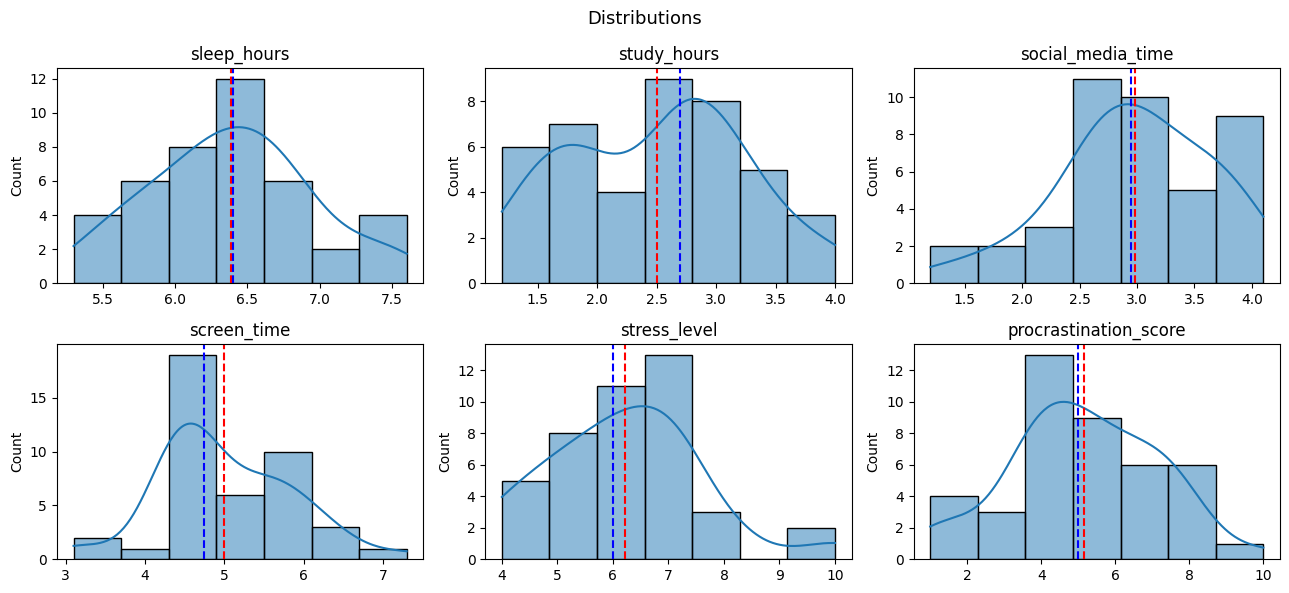

In [10]:
cols = ['sleep_hours', 'study_hours', 'social_media_time', 'screen_time', 'stress_level', 'procrastination_score']
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.axvline(df[col].mean(), color='red', linestyle='--')
    ax.axvline(df[col].median(), color='blue', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### Procrastination Score Over Time

This shows how my procrastination score changed day by day over the 42 days I tracked myself.

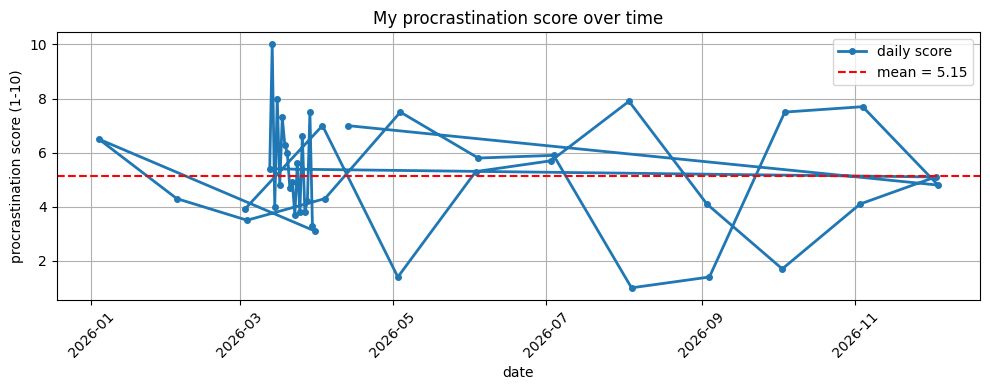

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['date'], df['procrastination_score'], marker='o', linewidth=2, markersize=4, label='daily score')
ax.axhline(df['procrastination_score'].mean(), linestyle='--', color='red', label=f'mean = {df["procrastination_score"].mean():.2f}')
ax.set_xlabel('date')
ax.set_ylabel('procrastination score (1-10)')
ax.set_title('My procrastination score over time')
ax.legend()
ax.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scatter Plots

Here I check if there is a visible relationship between each habit and my procrastination score. The red line is the trend line.

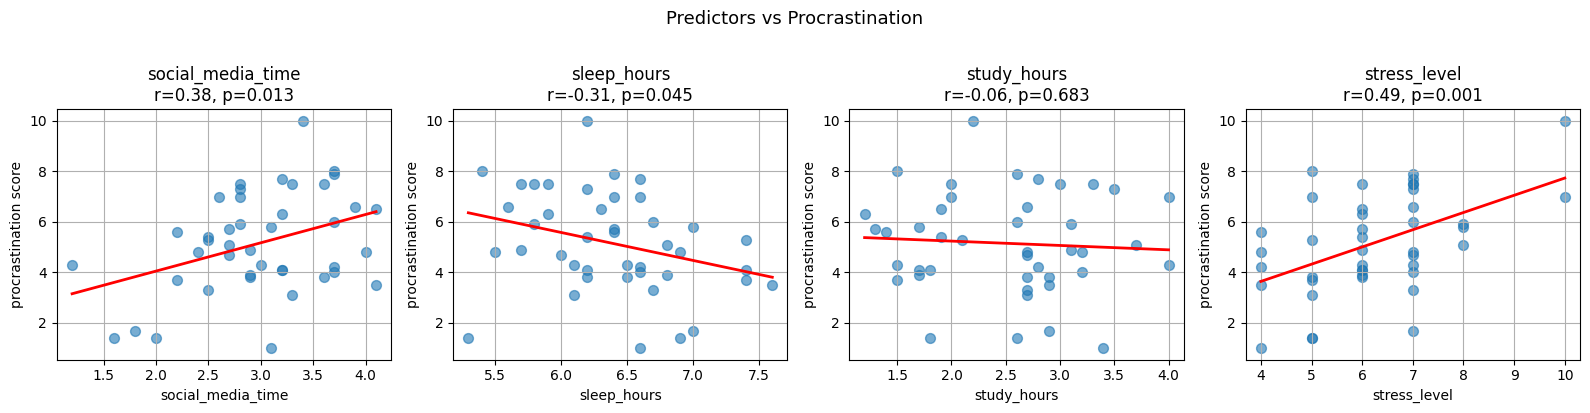

In [12]:
predictors = ['social_media_time', 'sleep_hours', 'study_hours', 'stress_level']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df['procrastination_score'], alpha=0.6, s=50)
    m, b = np.polyfit(df[col], df['procrastination_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2)
    r = fcorr(df[col].values, df['procrastination_score'].values)
    _, p = stats.pearsonr(df[col], df['procrastination_score'])
    ax.set_title(f'{col}\nr={r:.2f}, p={p:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('procrastination score')
    ax.grid()
plt.suptitle('Predictors vs Procrastination', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Correlation Matrix

This heatmap shows how all variables correlate with each other. Values close to 1 or -1 mean a strong relationship, values close to 0 mean no relationship.

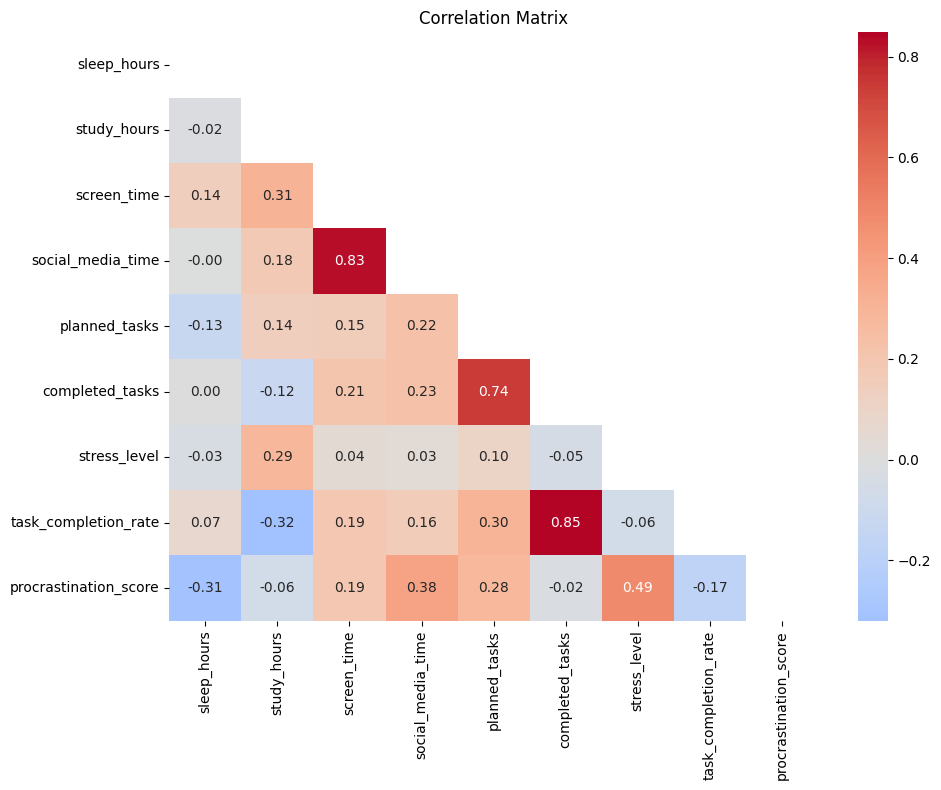

In [13]:
numeric_cols = ['sleep_hours', 'study_hours', 'screen_time', 'social_media_time',
                'planned_tasks', 'completed_tasks', 'stress_level',
                'task_completion_rate', 'procrastination_score']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Pair Plot

This shows the relationship between the most important variables all at once. Each plot compares two variables against each other.

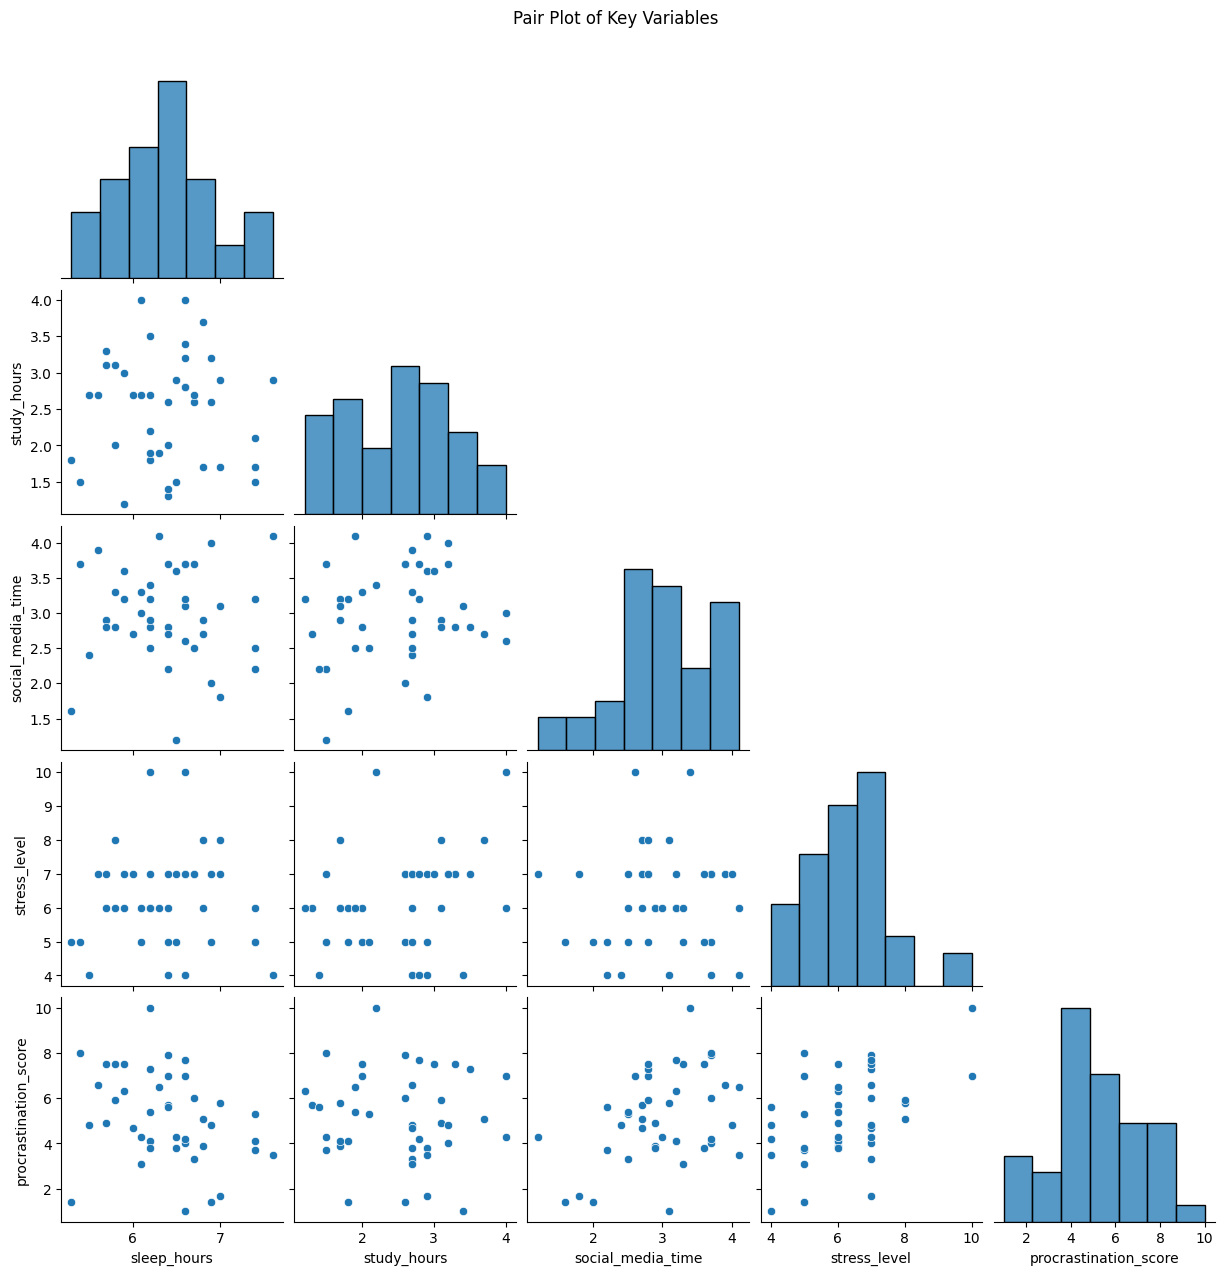

In [14]:
pair_cols = ['sleep_hours', 'study_hours', 'social_media_time', 'stress_level', 'procrastination_score']
sns.pairplot(df[pair_cols], corner=True)
plt.suptitle('Pair Plot of Key Variables', y=1.02)
plt.show()

### Weekday vs Weekend

Here I compare my procrastination, social media usage and study hours between weekdays and weekends to see if there is a difference.

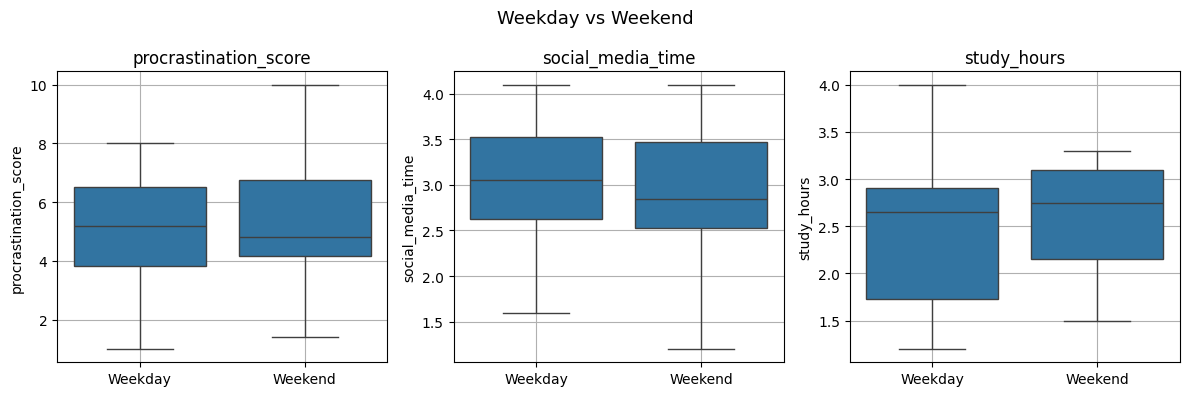

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['procrastination_score', 'social_media_time', 'study_hours']):
    sns.boxplot(data=df, x='is_weekend', y=col, ax=ax)
    ax.set_xticklabels(['Weekday', 'Weekend'])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.grid()
plt.suptitle('Weekday vs Weekend', fontsize=13)
plt.tight_layout()
plt.show()

## Hypothesis Testing


### H1: Does more social media mean more procrastination?

- **H0**: Social media time has no correlation with procrastination score.
- **H1**: More social media time means higher procrastination.
- **Test**: Pearson correlation (one-tailed), α = 0.05

In [16]:
r, p_two = stats.pearsonr(df['social_media_time'], df['procrastination_score'])
p_one = p_two / 2
print(f'r = {r:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r > 0:
    print('Result: Reject H0 – social media is positively correlated with procrastination')
else:
    print('Result: Fail to reject H0')

r = 0.378
p-value (one-tailed) = 0.0067
Result: Reject H0 – social media is positively correlated with procrastination


### H2: Does less sleep mean more procrastination?

- **H0**: Sleep hours have no correlation with procrastination score.
- **H1**: Less sleep means higher procrastination.
- **Test**: Pearson correlation (one-tailed), α = 0.05

In [17]:
r, p_two = stats.pearsonr(df['sleep_hours'], df['procrastination_score'])
p_one = p_two / 2
print(f'r = {r:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r < 0:
    print('Result: Reject H0 – less sleep is correlated with more procrastination')
else:
    print('Result: Fail to reject H0')

r = -0.311
p-value (one-tailed) = 0.0225
Result: Reject H0 – less sleep is correlated with more procrastination


### H3: Do I procrastinate more on weekends?

- **H0**: My procrastination score is the same on weekdays and weekends.
- **H1**: I procrastinate more on weekends.
- **Test**: Independent samples t-test (one-tailed), α = 0.05

In [18]:
weekday = df[df['is_weekend'] == False]['procrastination_score']
weekend = df[df['is_weekend'] == True]['procrastination_score']
t_stat, p_two = stats.ttest_ind(weekend, weekday)
p_one = p_two / 2
print(f'Weekday mean = {weekday.mean():.2f}')
print(f'Weekend mean = {weekend.mean():.2f}')
print(f't = {t_stat:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and t_stat > 0:
    print('Result: Reject H0 – weekends have significantly higher procrastination')
else:
    print('Result: Fail to reject H0')

Weekday mean = 5.13
Weekend mean = 5.22
t = 0.131
p-value (one-tailed) = 0.4483
Result: Fail to reject H0


### H4: Does completing more tasks mean less procrastination?

- **H0**: Task completion rate has no relationship with procrastination score.
- **H1**: Completing more tasks is linked to lower procrastination.
- **Test**: Spearman correlation (one-tailed), α = 0.05

In [19]:
r_sp, p_two = stats.spearmanr(df['task_completion_rate'], df['procrastination_score'])
p_one = p_two / 2
print(f'Spearman r = {r_sp:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r_sp < 0:
    print('Result: Reject H0 – completing more tasks is linked to less procrastination')
else:
    print('Result: Fail to reject H0')

Spearman r = -0.205
p-value (one-tailed) = 0.0966
Result: Fail to reject H0


#Explanation for each Hypothesis Test or Summary

First
I wanted to check if using social media more means I procrastinate more. Turns out yes, there is a real connection (r = 0.378, p = 0.0067). So the more time I spend on Instagram Reels or whatever, the higher my procrastination score gets that day.

Second
I wanted to check if sleeping less makes me procrastinate more. And yeah it does (r = -0.311, p = 0.0225).

Third
I wanted to see if I procrastinate more on weekends. The test showed there is no significant difference actually. So I procrastinate pretty much the same amount every day of the week.

Fourth
I wanted to check if finishing more of my planned tasks means I procrastinate less. The result showed yes there is a connection.